## The Unreasonable Effectiveness of Linear Regression

In [1]:
import numpy as np
import polars as pl

### Regresión Lineal y Ortogonalización en Inferencia Causal

En este capítulo añadirás la primera gran técnica de *des-biasing* a tu arsenal de inferencia causal: la **regresión lineal** u *ordinary least squares* (OLS) y la **ortogonalización**.

- **¿Por qué es importante la regresión lineal en causalidad?**  
    La regresión lineal permite ajustar por *confundidores* al estimar la relación entre un tratamiento ($T$) y un resultado ($Y$). Es decir, nos ayuda a aislar el efecto causal de $T$ sobre $Y$ controlando por variables que podrían sesgar la estimación.

- **Ortogonalización:**  
    Más allá de ajustar por confundidores, la ortogonalización es un concepto poderoso que surge de la regresión lineal. Consiste en "separar" el tratamiento de los confundidores, de modo que el efecto estimado sea puramente causal.

> Esta idea será fundamental cuando empieces a utilizar modelos de *machine learning* para inferencia causal, ya que permite generalizar el ajuste de confundidores más allá de los modelos lineales.

---



## Regression in A/B Tests

In [2]:
data = pl.read_csv("../data/rec_ab_test.csv")
data

recommender,age,tenure,watch_time
str,i64,i64,f64
"""challenger""",15,1,2.39
"""challenger""",27,1,2.32
"""benchmark""",17,0,2.74
"""benchmark""",34,1,1.92
"""benchmark""",14,1,2.47
…,…,…,…
"""benchmark""",18,0,2.13
"""benchmark""",16,0,1.7
"""benchmark""",15,0,1.25


- **En un A/B test aleatorizado**, comparar la media de los grupos (challenger vs. control) estima directamente el ATE (Average Treatment Effect).
- **Modelo de regresión lineal simple:**  
    $$
    \text{WatchTime}_i = \beta_0 + \beta_1 \cdot \text{challenger}_i + e_i
    $$
    - $\text{challenger}_i$: 1 si el usuario recibió la nueva versión, 0 si no.
    - $\beta_0$: media del grupo control.
    - $\beta_1$: diferencia de medias (ATE).
- **Ventajas de la regresión:**
    - $\beta_1$ estima el efecto causal del tratamiento.
    - Proporciona error estándar, intervalo de confianza y p-valor para $\beta_1$.
    - Si la asignación es aleatoria, no necesitas ajustar por confundidores: regresión y diferencia de medias son equivalentes.
- **Conclusión:**  
    La regresión lineal en A/B tests aleatorizados es una forma eficiente de obtener el ATE y toda la inferencia estadística asociada.


In [3]:
import statsmodels.formula.api as smf

# Ajustamos el modelo de regresión lineal
result = smf.ols('watch_time ~ C(recommender)', data=data.to_pandas()).fit()

# Mostramos la tabla de coeficientes
result.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2.0491,0.058,35.367,0.000,1.935,2.163
C(recommender)[T.challenger],0.1427,0.095,1.501,0.134,-0.044,0.330


In [4]:
data.filter(pl.col("recommender") == 'benchmark').select(pl.col("watch_time").mean())

watch_time
f64
2.049064


In [5]:
(
    data.group_by("recommender")
        .agg(pl.col("watch_time").mean().alias("mean_watch_time"))
)

recommender,mean_watch_time
str,f64
"""challenger""",2.19175
"""benchmark""",2.049064


## Notas clave sobre regresión en A/B tests
- **Intercepto ($\beta_0$):** Es la media de `watch_time` para el grupo benchmark (recomendador antiguo).
- **Coeficiente challenger ($\beta_1$):** Es la diferencia de medias entre challenger y benchmark. Si es positivo, el nuevo recomendador aumenta el tiempo de visualización.
- **Interpretación causal:** Gracias a la aleatorización, $\beta_1$ estima el efecto causal promedio (ATE) de cambiar al nuevo recomendador.
- **Cálculo de medias:**
    - Grupo benchmark: $\beta_0$
    - Grupo challenger: $\beta_0 + \beta_1$
- **Significancia estadística:** Si el intervalo de confianza de $\beta_1$ incluye el cero, el efecto no es estadísticamente significativo.
- **Ventaja de la regresión:** Obtienes el ATE, su error estándar, intervalo de confianza y p-valor en un solo paso.
- **¡Ojo!** En estudios observacionales, necesitas ajustar por confundidores para que la interpretación causal sea válida.

## Adjusting with Regression

In [6]:
risk_data = pl.read_csv("../data/risk_data.csv")
risk_data

wage,educ,exper,married,credit_score1,credit_score2,credit_limit,default
f64,i64,i64,i64,f64,f64,f64,i64
950.0,11,16,1,500.0,518.0,3200.0,0
780.0,11,7,1,414.0,429.0,1700.0,0
1230.0,14,9,1,586.0,571.0,4200.0,0
1040.0,15,8,1,379.0,411.0,1500.0,0
1000.0,16,1,1,379.0,518.0,1800.0,0
…,…,…,…,…,…,…,…
840.0,12,13,1,466.0,482.0,2400.0,0
700.0,15,16,1,328.0,393.0,1100.0,0
930.0,14,16,1,552.0,339.0,1700.0,0


In [7]:
risk_data.describe()

statistic,wage,educ,exper,married,credit_score1,credit_score2,credit_limit,default
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1061.518,13.48886,11.55078,0.89612,471.10254,487.86192,2848.57,0.1508
"""std""",412.304605,2.20769,4.36497,0.305108,113.401589,117.063919,1372.623633,0.357857
"""min""",120.0,9.0,1.0,0.0,34.0,36.0,200.0,0.0
"""25%""",770.0,12.0,8.0,1.0,397.0,411.0,1900.0,0.0
"""50%""",1010.0,12.0,11.0,1.0,466.0,482.0,2700.0,0.0
"""75%""",1270.0,16.0,15.0,1.0,534.0,571.0,3700.0,0.0
"""max""",3310.0,18.0,23.0,1.0,1034.0,1036.0,8500.0,1.0


### Contexto: Efecto del Límite de Crédito sobre el Default

- **Tratamiento ($T$):**  
    $credit\_limit$ (límite de crédito, variable continua)

- **Resultado ($Y$):**  
    $default$ (variable binaria: 1 si el cliente incumplió, 0 si no)

- **Confundidores ($X$):**  
    $wage$ (salario), $educ$ (años de educación), $exper$ (años de experiencia), $married$ (estado civil), $credit\_score1$, $credit\_score2$, etc.

---

**Pregunta causal:**  
> ¿Cuál es el efecto causal de aumentar el límite de crédito ($T$) sobre la probabilidad de default ($Y$), ajustando por los posibles confundidores ($X$)?

$$
Y = f(T, X) \\
\text{Queremos estimar: } E[Y \mid do(T = t)]
$$


In [8]:
model = smf.ols("default ~ credit_limit", data=risk_data.to_pandas()).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.2192,0.004,59.715,0.000,0.212,0.226
credit_limit,-2.402e-05,1.16e-06,-20.689,0.000,-2.63e-05,-2.17e-05


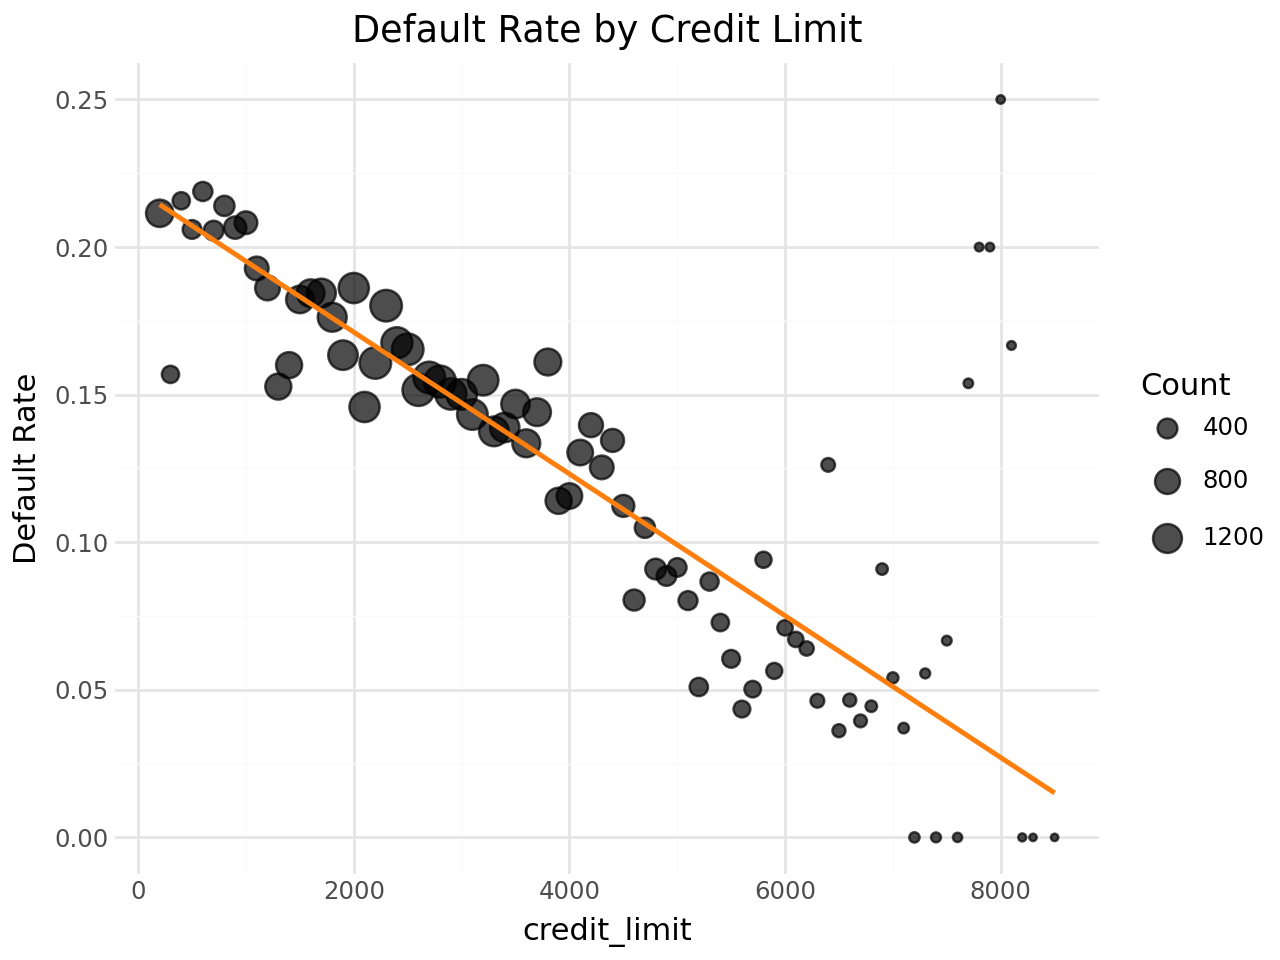

In [ ]:
import polars as pl
from plotnine import *

plt_df = (
    risk_data
    .group_by("credit_limit")
    .agg([
        pl.col("default").mean(),       # Calcula el promedio de default
        pl.len().alias("size")          # Cuenta las filas (equivalente a sum size)
    ])
    .sort("credit_limit")               # Ordenamos para que la línea del gráfico salga bien
)

preds = model.predict(plt_df.to_pandas())

# Añadimos la columna de predicción al DataFrame de Polars
plt_df = plt_df.with_columns(
    prediction = pl.Series(preds)
)

(
    ggplot(plt_df, aes(x="credit_limit")) +
    
    # Capa 1: Los puntos (sns.scatterplot)
    # Mapeamos 'size' al tamaño para tener las burbujas
    geom_point(aes(y="default", size="size"), alpha=0.7) +
    
    # Capa 2: La línea de predicción (plt.plot)
    # Usamos la columna 'prediction' que calculaste
    geom_line(aes(y="prediction"), color="#ff7f0e", size=1) + # color C1 es naranja aprox
    
    # Ajustes visuales para que se vea igual
    labs(
        title="Default Rate by Credit Limit",
        y="Default Rate",
        size="Count" # Etiqueta de la leyenda de tamaño
    ) +
    theme_minimal()
)

In [ ]:
(
    risk_data.group_by(["credit_score1", "credit_score2"])
             .len()
             .sort("credit_score1")
             .head(10)
)

credit_score1,credit_score2,len
f64,f64,u32
34.0,500.0,1
34.0,339.0,1
52.0,518.0,1
69.0,393.0,1
69.0,357.0,1
69.0,214.0,1
86.0,446.0,1
103.0,250.0,1
103.0,446.0,1


In [53]:
formula = "default ~ credit_limit + wage + credit_score1 + credit_score2"
model = smf.ols(formula, data=risk_data.to_pandas()).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.4037,0.009,46.939,0.000,0.387,0.421
credit_limit,3.063e-06,1.54e-06,1.987,0.047,4.16e-08,6.08e-06
wage,-8.822e-05,6.07e-06,-14.541,0.000,-0.000,-7.63e-05
credit_score1,-4.175e-05,1.83e-05,-2.278,0.023,-7.77e-05,-5.82e-06
credit_score2,-0.0003,1.52e-05,-20.055,0.000,-0.000,-0.000
